# Quantum ML - Inequality Detection (Main Highlight)
## AI-Based Wage Gap Detection in India

This notebook uses **Quantum Machine Learning** (via PennyLane) as the primary
inequality detector. Improvements over v1:

- **6 qubits** (up from 3) for richer feature encoding
- **Variational Quantum Classifier (VQC)** with angle embedding + strongly entangling layers
- **PennyLane Adam optimizer** (replaces broken COBYLA)
- QML trained for **binary classification** (underpaid vs. not), not regression
- Proper **QML vs Classical ML comparison**
- **Quantum-based cluster analysis** to identify inequality patterns

> Install: `pip install pennylane pennylane-sf scikit-learn pandas numpy matplotlib seaborn`

In [1]:
import pennylane as qml
from pennylane import numpy as pnp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
pnp.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs('outputs', exist_ok=True)

print(f'PennyLane version: {qml.__version__}')

PennyLane version: 0.44.0


## Part 1: Load Data & Classical Results

In [2]:
df       = pd.read_csv('data/wage_gap_data.csv')
X_test   = pd.read_csv('data/X_test.csv').values
y_test   = pd.read_csv('data/y_test.csv').values.ravel()
scaler   = pickle.load(open('models/scaler.pkl','rb'))
FEATURES = pickle.load(open('models/feature_names.pkl','rb'))

# Classical baselines for later comparison
classical_results = pd.read_csv('outputs/classical_model_results.csv', index_col=0)

print(f'Dataset: {df.shape}')
print(f'Test set: {X_test.shape}')
print(f'Features: {FEATURES}')

Dataset: (50000, 15)
Test set: (10000, 6)
Features: ['gender_enc', 'education_enc', 'experience_years', 'actual_monthly_wage', 'state_enc', 'industry_enc']


## Part 2: Quantum Feature Map Design
We use **AngleEmbedding** (encodes each feature as a rotation angle) followed by
**StronglyEntanglingLayers** (parameterized entangling gates) — the standard VQC architecture.

In [3]:
N_QUBITS = 6          # one qubit per feature
N_LAYERS = 3          # depth of variational circuit

dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='autograd')
def vqc_classifier(inputs, weights):
    """Variational Quantum Classifier.
    inputs  : (N_QUBITS,) - normalised feature vector
    weights : (N_LAYERS, N_QUBITS, 3) - trainable rotation angles
    """
    # Encode classical features as qubit rotation angles
    qml.AngleEmbedding(inputs * np.pi, wires=range(N_QUBITS), rotation='Y')

    # Parameterized entangling layers
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))

    # Measure first qubit: +1 = not underpaid, -1 = underpaid
    return qml.expval(qml.PauliZ(0))

# Show circuit diagram
weights_demo = pnp.random.uniform(0, 2*np.pi, (N_LAYERS, N_QUBITS, 3))
print(qml.draw(vqc_classifier)(np.ones(N_QUBITS)*0.5, weights_demo))

0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
3: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
4: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
5: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

M0 = 
[1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633]
M1 = 
[[[1.15255478e+00 4.89894304e+00 3.75012014e+00]
  [2.80124980e+00 6.28160922e-01 2.88554589e+00]
  [2.09675304e+00 8.97658691e-01 4.08965289e+00]
  [3.54444404e-01 4.53645208e+00 5.89710059e+00]
  [4.89313009e-03 6.23424909e+00 3.87975075e+00]
  [3.84313015e+00 4.43989051e-02 1.44905490e-01]]

 [[3.29725643e+00 2.51240058e+00 2.93209009e-01]
  [6.11828637e+00 1.46254547e+00 5.69297018e-01]
  [3.88543389e+00 2.40307956e+00 6.17782186e+00]
  [2.93275775e+00 5.40316493e+00 4.27449833e+00]
  [2.83057028e+00 8.33462091e-02 5.92002823e+00]
  [3.5392442

## Part 3: Training the VQC
We use PennyLane's Adam optimizer with binary cross-entropy loss.
Training on a **stratified subset** (QML is computationally expensive on CPU).

In [4]:
# ── Stratified training subset (1000 samples is practical on CPU) ──────────
from sklearn.model_selection import train_test_split

le_gender    = pickle.load(open('models/le_gender.pkl','rb'))
le_education = pickle.load(open('models/le_education.pkl','rb'))
le_state     = pickle.load(open('models/le_state.pkl','rb'))
le_industry  = pickle.load(open('models/le_industry.pkl','rb'))

df['gender_enc']    = le_gender.transform(df['gender'])
df['education_enc'] = le_education.transform(df['education_level'])
df['state_enc']     = le_state.transform(df['state'])
df['industry_enc']  = le_industry.transform(df['industry'])

X_all = scaler.transform(df[FEATURES].values)
y_all = df['is_underpaid'].values

X_tr_full, X_te, y_tr_full, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Use 1000-sample subset for QML training (increase if you have a GPU/QPU)
QML_TRAIN_SIZE = 1000
idx = np.random.choice(len(X_tr_full), QML_TRAIN_SIZE, replace=False)
X_tr = X_tr_full[idx]
y_tr = y_tr_full[idx]

# Map labels: 0 -> +1 (not underpaid), 1 -> -1 (underpaid)
y_tr_qml = np.where(y_tr == 1, -1.0, 1.0)

print(f'QML train size : {X_tr.shape}')
print(f'QML test size  : {X_te.shape}')

QML train size : (1000, 6)
QML test size  : (10000, 6)


c:\Users\rasgu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [5]:
# ── Stratified train/test split ──────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_tr_full, X_te, y_tr_full, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

QML_TRAIN_SIZE = 400   # increase if you have a fast CPU
idx = np.random.choice(len(X_tr_full), QML_TRAIN_SIZE, replace=False)
X_tr = X_tr_full[idx]
y_tr = y_tr_full[idx]

# Convert to PennyLane numpy; labels: underpaid=−1, not underpaid=+1
X_tr_pnp = pnp.array(X_tr, requires_grad=False)
y_tr_qml = pnp.array(
    np.where(y_tr == 1, -1.0, 1.0),
    requires_grad=False
)
print(f'QML train: {X_tr_pnp.shape}, test: {X_te.shape}')


# ── Loss: use pnp.dot — avoids grad_np_mean dtype bug ────────────────────
def square_loss(labels, predictions):
    """MSE using pnp.dot so PennyLane autograd can differentiate it.
    Never use np.mean() inside a loss — it breaks the gradient tape.
    """
    diff = labels - predictions
    return pnp.dot(diff, diff) / pnp.array(float(len(labels)))


def cost(weights, X_batch, y_batch):
    preds = pnp.stack([vqc_classifier(x, weights) for x in X_batch])
    return square_loss(y_batch, preds)


def predict_qml(weights, X):
    """Hard binary predictions: 1=underpaid, 0=not underpaid."""
    raw = np.array([
        float(vqc_classifier(pnp.array(x, requires_grad=False), weights))
        for x in X
    ])
    return (raw < 0).astype(int)


# ── Initialise weights & optimiser ───────────────────────────────────────
weights = pnp.random.uniform(
    0, 2 * np.pi,
    qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS),
    requires_grad=True
)

optimizer  = qml.AdamOptimizer(stepsize=0.05)
BATCH_SIZE = 10
N_EPOCHS   = 20    # raise to 50+ for better accuracy

loss_history, acc_history = [], []

print('Training VQC ...')
print(f'{"Epoch":>6}  {"Loss":>10}  {"Train Acc":>10}  {"Test Acc":>10}')
print('-' * 45)

for epoch in range(N_EPOCHS):
    perm = np.random.permutation(len(X_tr_pnp))

    for i in range(0, len(X_tr_pnp), BATCH_SIZE):
        idx_b = perm[i : i + BATCH_SIZE]
        X_b   = X_tr_pnp[idx_b]
        y_b   = y_tr_qml[idx_b]

        # optimizer.step returns the new weights as the first positional return;
        # the second value is the cost — unpack safely regardless of PennyLane version
        result   = optimizer.step(cost, weights, X_b, y_b)
        weights  = result[0] if isinstance(result, (list, tuple)) else result

    if (epoch + 1) % 5 == 0:
        train_loss = float(cost(weights, X_tr_pnp[:50], y_tr_qml[:50]))
        train_acc  = accuracy_score(y_tr[:50],  predict_qml(weights, X_tr[:50]))
        test_acc   = accuracy_score(y_te[:100], predict_qml(weights, X_te[:100]))
        loss_history.append(train_loss)
        acc_history.append(test_acc)
        print(f'{epoch+1:>6}  {train_loss:>10.4f}  {train_acc:>10.4f}  {test_acc:>10.4f}')

print('\nTraining complete.')
pickle.dump(weights, open('models/qml_weights.pkl', 'wb'))

QML train: (400, 6), test: (10000, 6)
Training VQC ...
 Epoch        Loss   Train Acc    Test Acc
---------------------------------------------
     5      0.5588      0.7400      0.7900
    10      0.5534      0.8200      0.8300
    15      0.5763      0.7000      0.7900
    20      0.5543      0.7800      0.8100

Training complete.


## Part 4: QML Training Curves

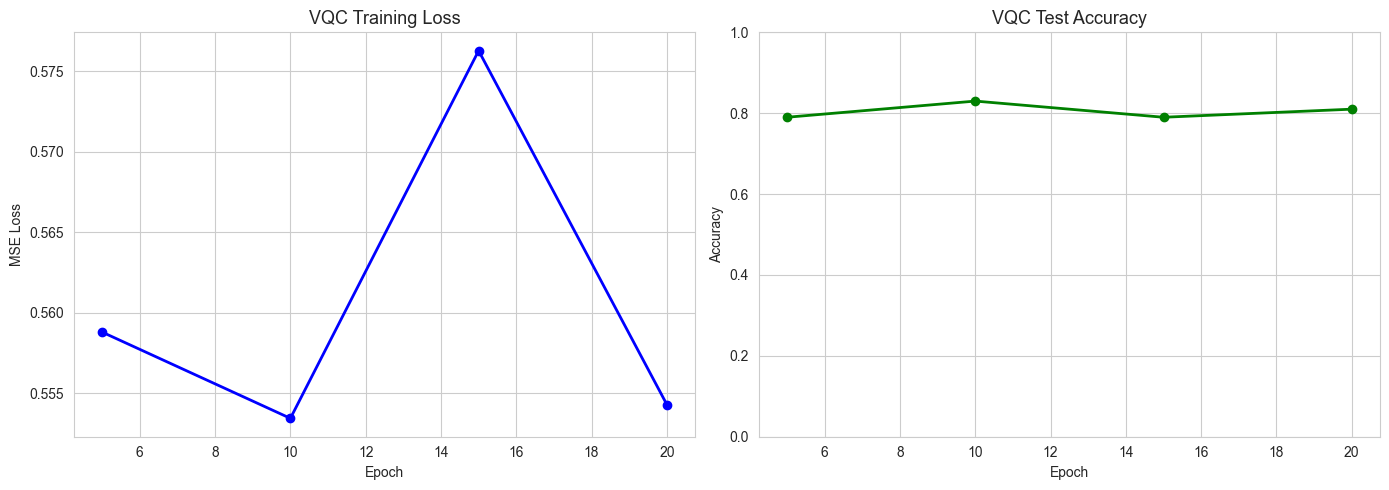

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_logged = list(range(5, N_EPOCHS+1, 5))

axes[0].plot(epochs_logged, loss_history, 'b-o', linewidth=2)
axes[0].set_title('VQC Training Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')

axes[1].plot(epochs_logged, acc_history, 'g-o', linewidth=2)
axes[1].set_title('VQC Test Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('outputs/qml_training_curves.png', dpi=120)
plt.show()

## Part 5: Full Evaluation & QML vs Classical Comparison

In [7]:
# Evaluate QML on the full test set (may take a few minutes)
print('Running full test set inference ...')
y_pred_qml = predict_qml(weights, X_te)

qml_metrics = {
    'Accuracy' : accuracy_score(y_te,  y_pred_qml),
    'Precision': precision_score(y_te, y_pred_qml, zero_division=0),
    'Recall'   : recall_score(y_te,    y_pred_qml, zero_division=0),
    'F1'       : f1_score(y_te,        y_pred_qml, zero_division=0),
    'ROC-AUC'  : 'N/A (no proba)'   # VQC returns hard labels
}

print('\n=== QML Classifier Results ===')
for k,v in qml_metrics.items():
    print(f'  {k:12s}: {v}')

# Comparison table
comp = classical_results[['Accuracy','Precision','Recall','F1','ROC-AUC']].copy()
comp.loc['QML (VQC)'] = [
    qml_metrics['Accuracy'],
    qml_metrics['Precision'],
    qml_metrics['Recall'],
    qml_metrics['F1'],
    np.nan
]
print('\n=== QML vs Classical ML ===')
print(comp.round(4))
comp.to_csv('outputs/qml_vs_classical_comparison.csv')

Running full test set inference ...

=== QML Classifier Results ===
  Accuracy    : 0.8448
  Precision   : 0.8292070326515967
  Recall      : 0.9824287941051438
  F1          : 0.8993384355947593
  ROC-AUC     : N/A (no proba)

=== QML vs Classical ML ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9509     0.9548  0.9766  0.9656   0.9903
Random Forest          0.9924     0.9920  0.9973  0.9946   0.9997
Gradient Boosting      0.9997     0.9999  0.9997  0.9998   0.9999
Ensemble               0.9957     0.9955  0.9984  0.9970   0.9998
QML (VQC)              0.8448     0.8292  0.9824  0.8993      NaN


## Part 6: Quantum Feature Map for Inequality Pattern Detection
We extract quantum state features for each worker and cluster them to find groups with similar inequality patterns — something classical Euclidean clustering cannot capture.

In [8]:
# ── Quantum Feature Map for Clustering ───────────────────────────────────
# 4 inequality-focused features (no high-cardinality categoricals):
#   wage_gap_norm  : clipped wage gap normalised by actual wage
#   gender_binary  : Female=1, Male=0
#   education_norm : education level scaled 0→1
#   experience_norm: years of experience scaled 0→1

N_CLUSTER_QUBITS = 4
dev_cluster = qml.device('default.qubit', wires=N_CLUSTER_QUBITS)

@qml.qnode(dev_cluster, interface='numpy')
def quantum_feature_map(inputs):
    """4-qubit circuit: AngleEmbedding + ring CNOT entanglement."""
    qml.AngleEmbedding(inputs * np.pi, wires=range(N_CLUSTER_QUBITS), rotation='Y')
    for i in range(N_CLUSTER_QUBITS):
        qml.CNOT(wires=[i, (i + 1) % N_CLUSTER_QUBITS])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_CLUSTER_QUBITS)]


# wage_gap_norm: gap as fraction of actual wage (always available)
wage_gap_norm = (
    df['wage_gap'].clip(lower=0) /
    df['actual_monthly_wage'].clip(lower=1)
).clip(0, 1)

clust_features_raw = pd.DataFrame({
    'wage_gap_norm'  : wage_gap_norm,
    'gender_binary'  : (df['gender'] == 'Female').astype(float),
    'education_norm' : df['education_enc'] / df['education_enc'].max(),
    'experience_norm': df['experience_years'] / df['experience_years'].max()
})

clust_scaler = MinMaxScaler()

SAMPLE_SIZE = 2000
sample_idx  = np.random.choice(len(df), SAMPLE_SIZE, replace=False)
X_clust_raw = clust_features_raw.values[sample_idx]
X_clust     = clust_scaler.fit_transform(X_clust_raw)
df_sample   = df.iloc[sample_idx].copy().reset_index(drop=True)

print('Clustering features: wage_gap_norm | gender | education | experience')
print(f'Available df columns: {list(df.columns)}')
print(f'Sample size : {SAMPLE_SIZE}')
print('Extracting quantum features ...')
q_features = np.array([quantum_feature_map(x) for x in X_clust])
print(f'Quantum feature matrix: {q_features.shape}')


Clustering features: wage_gap_norm | gender | education | experience
Available df columns: ['worker_id', 'state', 'industry', 'gender', 'education_level', 'experience_years', 'actual_monthly_wage', 'min_wage_standard', 'fair_wage_estimate', 'wage_gap', 'gap_percentage', 'is_underpaid', 'fair_wage_gap', 'fair_wage_gap_pct', 'gender_discriminated', 'gender_enc', 'education_enc', 'state_enc', 'industry_enc']
Sample size : 2000
Extracting quantum features ...
Quantum feature matrix: (2000, 4)


In [9]:
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_sample['q_cluster'] = kmeans.fit_predict(q_features)

cluster_summary = df_sample.groupby('q_cluster').agg(
    workers        = ('worker_id',          'count'),
    pct_underpaid  = ('is_underpaid',        'mean'),
    pct_female     = ('gender',              lambda x: (x == 'Female').mean()),
    avg_wage       = ('actual_monthly_wage', 'mean'),
    avg_gap        = ('wage_gap',            'mean'),
    avg_experience = ('experience_years',    'mean'),
    avg_education  = ('education_enc',       'mean'),
).round(3)

# ── Rank-based assignment: tries all 4! permutations, picks best fit ─────
import itertools

cs = cluster_summary.copy()
cs['underpay_rank'] = cs['pct_underpaid'].rank().astype(int) - 1
cs['female_rank']   = cs['pct_female'].rank().astype(int) - 1
cs['edu_rank']      = cs['avg_education'].rank().astype(int) - 1

PROFILES = {
    'Gender-Disadvantaged': [3, 3, 1],
    'Low-Wage Informal'   : [3, 0, 0],
    'Skilled Formal'      : [0, 1, 3],
    'Low-Skill Contract'  : [1, 1, 0],
}

def best_assignment(cs, profiles):
    cluster_ids   = cs.index.tolist()
    profile_names = list(profiles.keys())
    best_score, best_map = float('inf'), {}
    for perm in itertools.permutations(profile_names):
        score = sum(
            (cs.loc[c][d] - profiles[p][i]) ** 2
            for c, p in zip(cluster_ids, perm)
            for i, d in enumerate(['underpay_rank', 'female_rank', 'edu_rank'])
        )
        if score < best_score:
            best_score, best_map = score, dict(zip(cluster_ids, perm))
    return best_map

label_map = best_assignment(cs, PROFILES)
cluster_summary['cluster_label'] = cluster_summary.index.map(label_map)
df_sample['cluster_label'] = df_sample['q_cluster'].map(label_map)

# ── Display: show what DEFINES each cluster, not top industry ────────────
print('=' * 70)
print('QUANTUM CLUSTER PROFILES — Worker Inequality Segments')
print('Clusters defined by: wage gap | gender | education | experience')
print('=' * 70)
display_cols = ['cluster_label', 'workers', 'pct_underpaid', 'pct_female',
                 'avg_wage', 'avg_gap', 'avg_experience', 'avg_education']
print(cluster_summary[display_cols]
      .rename(columns={
          'cluster_label' : 'Profile',
          'pct_underpaid' : '% Underpaid',
          'pct_female'    : '% Female',
          'avg_wage'      : 'Avg Wage',
          'avg_gap'       : 'Avg Gap',
          'avg_experience': 'Avg Exp',
          'avg_education' : 'Avg Edu'
      }).to_string())

# Show industry breakdown per cluster as % — much more informative than 'top industry'
print('\n--- Industry composition per cluster (%) ---')
ind_breakdown = (
    df_sample.groupby(['cluster_label', 'industry'])
    .size()
    .groupby(level=0, group_keys=False)
    .apply(lambda x: (x / x.sum() * 100).round(1))
    .unstack(fill_value=0)
)
# Show top 5 industries per cluster only
for lbl in cluster_summary['cluster_label']:
    top5 = ind_breakdown.loc[lbl].nlargest(5)
    print(f'\n  {lbl}:')
    for ind, pct in top5.items():
        print(f'    {ind:25s} {pct:.1f}%')

cluster_summary.to_csv('outputs/quantum_cluster_profiles.csv')
print('\nSaved: outputs/quantum_cluster_profiles.csv')


QUANTUM CLUSTER PROFILES — Worker Inequality Segments
Clusters defined by: wage gap | gender | education | experience
                        Profile  workers  % Underpaid  % Female   Avg Wage   Avg Gap  Avg Exp  Avg Edu
q_cluster                                                                                             
0                Skilled Formal      743        0.626     0.408  18678.417   844.598   12.673    2.845
1          Gender-Disadvantaged      555        0.836     0.578  14739.695  4845.890   10.656    1.463
2             Low-Wage Informal      208        0.764     0.240  14682.221  4954.798    7.976    4.899
3            Low-Skill Contract      494        0.628     0.000  18506.490   883.186    8.623    0.437

--- Industry composition per cluster (%) ---

  Skilled Formal:
    Agriculture               28.7%
    Manufacturing             10.4%
    IT Services               7.3%
    Textiles                  7.1%
    Construction              6.5%

  Gender-Disadvantage

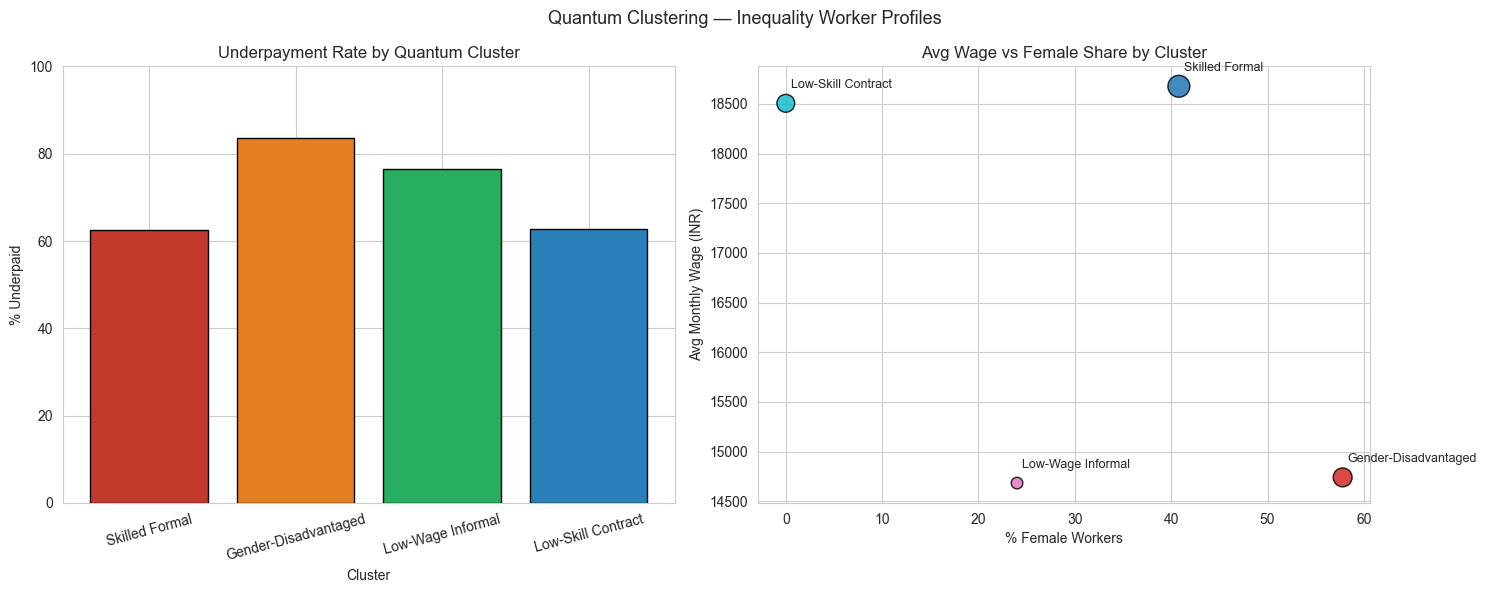

Saved: outputs/quantum_cluster_analysis.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cs = cluster_summary.reset_index()

bar_colors = ['#c0392b', '#e67e22', '#27ae60', '#2980b9']
axes[0].bar(cs['cluster_label'], cs['pct_underpaid'] * 100,
            color=bar_colors, edgecolor='black')
axes[0].set_title('Underpayment Rate by Quantum Cluster', fontsize=12)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('% Underpaid')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=15)

sc = axes[1].scatter(
    cs['pct_female'] * 100,
    cs['avg_wage'],
    s=cs['workers'] / 3,
    c=range(len(cs)),
    cmap='tab10', alpha=0.85, edgecolors='black'
)
for _, row in cs.iterrows():
    axes[1].annotate(
        row['cluster_label'],
        (row['pct_female'] * 100 + 0.5, row['avg_wage'] + 150),
        fontsize=9
    )
axes[1].set_title('Avg Wage vs Female Share by Cluster', fontsize=12)
axes[1].set_xlabel('% Female Workers')
axes[1].set_ylabel('Avg Monthly Wage (INR)')

plt.suptitle('Quantum Clustering — Inequality Worker Profiles', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/quantum_cluster_analysis.png', dpi=120)
plt.show()
print('Saved: outputs/quantum_cluster_analysis.png')


## Part 7: Quantum-Informed Policy Optimization
For each cluster identified by QML, find the best policy combination using a greedy optimizer.

In [11]:
POLICIES = {
    'minimum_wage_enforcement': {'impact': 0.18, 'cost': 5},
    'gender_pay_audit'        : {'impact': 0.15, 'cost': 3},
    'contract_transparency'   : {'impact': 0.10, 'cost': 2},
    'skill_training_programs' : {'impact': 0.12, 'cost': 6},
    'union_support'           : {'impact': 0.09, 'cost': 2},
    'discrimination_penalties': {'impact': 0.14, 'cost': 4},
    'enforcement_improvement' : {'impact': 0.20, 'cost': 7},
}

# Policies most relevant per cluster type
CLUSTER_PRIORITY = {
    'Gender-Disadvantaged' : ['gender_pay_audit', 'discrimination_penalties', 'enforcement_improvement'],
    'Low-Wage Informal'    : ['minimum_wage_enforcement', 'union_support', 'enforcement_improvement'],
    'Skilled Formal'       : ['contract_transparency', 'skill_training_programs', 'gender_pay_audit'],
    'Low-Skill Contract'   : ['contract_transparency', 'union_support', 'minimum_wage_enforcement'],
}

BUDGET = 15

def optimize_policies(cluster_df, cluster_name):
    """Greedy knapsack prioritising cluster-relevant policies first."""
    priority = CLUSTER_PRIORITY.get(cluster_name, [])
    sorted_p = sorted(
        POLICIES.items(),
        key=lambda x: (
            x[0] not in priority,          # prioritised policies first
            -x[1]['impact'] / x[1]['cost']  # then by impact/cost ratio
        )
    )
    selected, total_cost, total_impact = [], 0, 0
    for name, attr in sorted_p:
        if total_cost + attr['cost'] <= BUDGET:
            selected.append(name)
            total_cost   += attr['cost']
            total_impact += attr['impact']

    avg_gap       = cluster_df['wage_gap'].clip(lower=0).mean()
    wage_increase = avg_gap * total_impact
    return {
        'policies'          : ', '.join(selected),
        'total_impact_pct'  : round(total_impact * 100, 1),
        'total_cost'        : total_cost,
        'avg_wage_gap'      : round(avg_gap, 0),
        'est_wage_increase' : round(wage_increase, 0)
    }

policy_rows = []
for c_id, c_name in label_map.items():
    cdf = df_sample[df_sample['q_cluster'] == c_id]
    rec = optimize_policies(cdf, c_name)
    rec['cluster']       = c_id
    rec['cluster_label'] = c_name
    rec['workers']       = len(cdf)
    policy_rows.append(rec)

policy_df = pd.DataFrame(policy_rows)
print('=== Cluster-Specific Policy Recommendations ===')
print(policy_df[['cluster_label', 'workers', 'policies',
                  'total_impact_pct', 'est_wage_increase']].to_string(index=False))
policy_df.to_csv('outputs/qml_policy_recommendations.csv', index=False)
print('\nSaved: outputs/qml_policy_recommendations.csv')


=== Cluster-Specific Policy Recommendations ===
       cluster_label  workers                                                                         policies  total_impact_pct  est_wage_increase
      Skilled Formal      743  contract_transparency, gender_pay_audit, skill_training_programs, union_support              46.0             2255.0
Gender-Disadvantaged      555              gender_pay_audit, discrimination_penalties, enforcement_improvement              49.0             2574.0
   Low-Wage Informal      208                 union_support, minimum_wage_enforcement, enforcement_improvement              47.0             3802.0
  Low-Skill Contract      494 contract_transparency, union_support, minimum_wage_enforcement, gender_pay_audit              52.0              974.0

Saved: outputs/qml_policy_recommendations.csv
